# Segmentação de Clientes de Varejo

Projeto A3 da disciplina de Inteligência Artificial.

Tema: Segmentação de clientes de uma empresa de varejo/supermercado usando algoritmos de aprendizado de máquina não supervisionado.

Algoritmos usados:
- K-Means Clustering
- DBSCAN

Dataset:
- Mall Customers Dataset

## 1. Introdução e objetivo do projeto

(pessoa 1 completar)

- qual é o problema do projeto;
- o que é segmentação de clientes;
- por que isso é útil para empresas de varejo/supermercado;
- qual é o objetivo da aplicação.

## 2. Descrição do dataset

(pessoa 1 completar)

explicar as colunas do dataset:
- CustomerID;
- Gender;
- Age;
- Annual Income (k$);
- Spending Score (1-100).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

Foram importadas as bibliotecas que vão ser usadas para ler os dados, manipular as informações, gerar gráficos, padronizar as variáveis e aplicar os algoritmos de agrupamento, como K-Means e DBSCAN.

In [ ]:
df=pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Nesta parte foi feita uma verificação inicial do dataset, olhando as informações gerais, estatísticas e se existem dados nulos. Isso ajuda a evitar problema antes de aplicar o algoritmo.


## 3. Análise exploratória dos dados

(pessoa 2 completar)

Nesta seção, criar gráficos como:
- quantidade de clientes por gênero;
- distribuição de idade;
- distribuição de renda anual;
- distribuição do spending score;
- relação entre renda anual e spending score.

In [ ]:
X=df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Para começar o K-Means, foram escolhidas duas colunas principais: renda anual(Annual Income (k$)) e pontuação de gasto(Spending Score (1-100)). Essas informações ajudam a separar clientes de acordo com quanto eles ganham e quanto costumam gastar.


## 4. Pré-processamento dos dados

ja fiz a seleção das variáveis para agrupamento e padronização com StandardScaler

pessoa 3 pode complementar com:
- explicação sobre remoção/ignorância de CustomerID;
- verificação de dados duplicados;
- tratamento da variável Gender, caso o grupo decida usar;
- justificativa das variáveis escolhidas.

In [ ]:
# Padronização dos dados

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
# Transformando os dados padronizados em uma tabela para visualizar melhor

X_scaled_df=pd.DataFrame(
    X_scaled,
    columns=["Renda Anual Padronizada", "Pontuação de Gasto Padronizada"]
)
X_scaled_df.head()

,Renda Anual Padronizada,Pontuação de Gasto Padronizada
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


A padronização foi feita com o StandardScaler. Ela deixa as variáveis em uma escala parecida.

Isso é importante porque o K-Means calcula distância entre os pontos. Se uma coluna tiver valores muito maiores que a outra, ela pode acabar pesando mais no resultado.


## 5. Segmentação com K-Means

Nesta etapa foi aplicado o K-Means, que separa os clientes em grupos parecidos de acordo com as variáveis escolhidas.

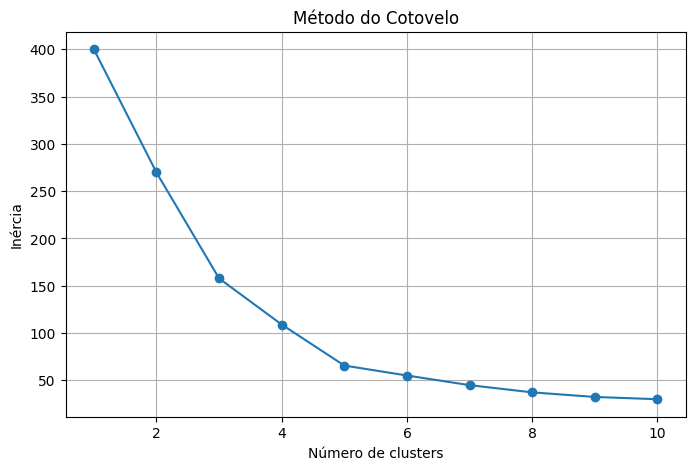

In [9]:
# Método do cotovelo para escolher o número de clusters

inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker="o")
plt.title("Método do Cotovelo")
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.grid(True)
plt.show()

O método do cotovelo foi usado para ajudar na escolha da quantidade de grupos. A ideia é olhar o ponto em que a queda da inércia começa a ficar menor. Esse ponto ajuda a decidir um valor de K.


In [10]:
# Cálculo do Silhouette Score para diferentes valores de K

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k} | Silhouette Score = {score:.3f}")

K = 2 | Silhouette Score = 0.321
K = 3 | Silhouette Score = 0.467
K = 4 | Silhouette Score = 0.494
K = 5 | Silhouette Score = 0.555
K = 6 | Silhouette Score = 0.540
K = 7 | Silhouette Score = 0.528
K = 8 | Silhouette Score = 0.455
K = 9 | Silhouette Score = 0.457
K = 10 | Silhouette Score = 0.443


O Silhouette Score foi utilizado como métrica para avaliar a qualidade dos agrupamentos. O valor varia de -1 a 1. Quanto mais próximo de 1, melhor a separação entre os clusters.

O valor K = 5 foi escolhido porque apresentou o melhor Silhouette Score entre os valores testados, indicando uma boa separação entre os grupos.

In [ ]:
# Aplicação do K-Means com 5 clusters

kmeans=KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster_KMeans"]=kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_KMeans
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Após a análise do método do cotovelo e do Silhouette Score, foi escolhido o valor K = 5 para segmentar os clientes em cinco grupos.

In [12]:
# Quantidade de clientes em cada grupo

df["Cluster_KMeans"].value_counts().sort_index()

Cluster_KMeans
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Essa contagem mostra quantos clientes ficaram em cada grupo criado pelo K-Means.


In [13]:
# Média de renda anual e pontuação de gasto por grupo

df.groupby("Cluster_KMeans")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster_KMeans,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


As médias de renda anual e pontuação de gasto ajudam a entender o perfil de cada grupo. Com isso, dá para dar um nome mais fácil para cada segmento de cliente.


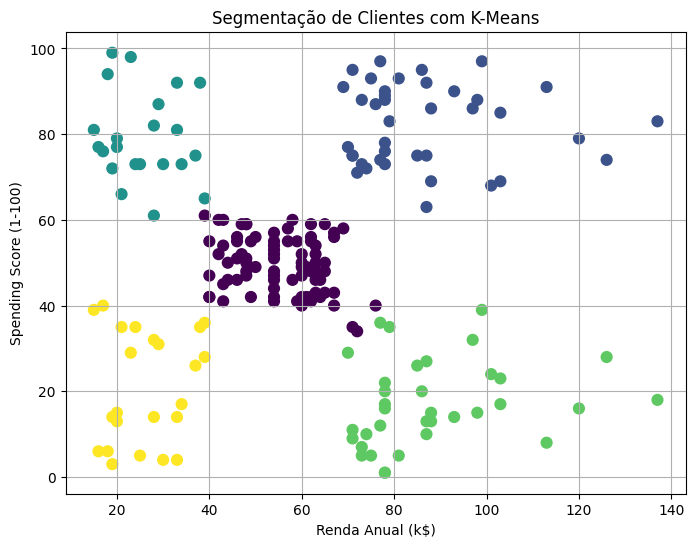

In [14]:
# Visualização dos clusters gerados pelo K-Means

plt.figure(figsize=(8, 6))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster_KMeans"],
    s=60
)

plt.title("Segmentação de Clientes com K-Means")
plt.xlabel("Renda Anual (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(True)
plt.show()

O gráfico mostra a segmentação dos clientes com base na renda anual e na pontuação de gasto. Cada cor representa um grupo diferente identificado pelo algoritmo K-Means.

## 6. Interpretação dos grupos do K-Means

Com base nas médias de renda anual e pontuação de gasto, os grupos foram interpretados da seguinte forma:

Grupo 0: clientes com renda média e gasto médio.
Grupo 1: clientes com alta renda e alto gasto.
Grupo 2: clientes com baixa renda e alto gasto.
Grupo 3: clientes com alta renda e baixo gasto.
Grupo 4: clientes com baixa renda e baixo gasto.

Essa divisão pode ajudar uma empresa de varejo a pensar em campanhas diferentes para cada tipo de cliente.

## 7. Segmentação com DBSCAN
(pessoa 5 completar)

aplicar o algoritmo DBSCAN:
- testar valores de eps;
- testar valores de min_samples;
- criar os clusters;
- identificar ruídos/outliers;
- visualizar os grupos.

## 8. Comparação entre K-Means e DBSCAN

(pessoa 5 completar)
comparar:
- número de grupos encontrados;
- métricas de desempenho;
- facilidade de interpretação;
- presença de ruídos/outliers;
- vantagens e desvantagens de cada algoritmo.

## 9. Aplicação prática para campanhas de marketing
(pessoa 6 completar)

criar uma função simples para:
- receber os dados de um novo cliente;
- classificar o cliente em um grupo;
- mostrar o perfil do grupo;
- sugerir uma campanha de marketing personalizada.

## 10. Conclusão

(grupo completar)

Nesta seção, explicar:
- qual algoritmo funcionou melhor;
- como os grupos podem ajudar uma empresa de varejo;
- limitações do projeto;
- possíveis melhorias futuras.